# FFT Expansion and Frequency Analysis
This notebook provides a worked solution to the exercise on using the Fast Fourier Transform (FFT) for trigonometric expansion and frequency analysis, based on *Burden & Faires, Numerical Analysis,* Chapter 8.


## Exercise Statement
*Given the periodic function*

\[ f(x) = e^{\sin(2\pi x)} + 0.5\,\sin(6\pi x), \qquad x \in [0,1) \]

1. **Sampling.** Sample \(f\) at \(N=256\) equally spaced points.
2. **FFT.** Use the Fast Fourier Transform to obtain the complex Fourier coefficients \(\widehat{f}_k\).
3. **Spectrum.** Plot the magnitude spectrum \(|\widehat{f}_k|\).
4. **Truncation.** Construct an approximation by zeroing all coefficients with index |k|>10 and performing the inverse FFT.
5. **Error.** Compute the root‑mean‑square error between the original samples and the truncated reconstruction.
6. **Visualisation.** Plot the original and reconstructed functions on the same graph and comment on the quality of the approximation.


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1 – parameters and sampling
N = 256                       # number of sample points (power of two for FFT efficiency)
x = np.linspace(0, 1, N, endpoint=False)
f = np.exp(np.sin(2 * np.pi * x)) + 0.5 * np.sin(6 * np.pi * x)

f[:10]  # preview first few samples

array([1.        , 1.06162712, 1.12365666, 1.18588865, 1.24812403,
       1.31016568, 1.37181935, 1.43289463, 1.49320588, 1.55257311])

In [18]:
# Step 2 – forward FFT to obtain coefficients
F_hat = np.fft.fft(f)

# For plotting convenience move zero frequency to centre
F_shift = np.fft.fftshift(F_hat) / N  # normalise by N
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=1/N))

abs(F_hat[:10])

array([3.24112865e+02, 1.44680731e+02, 3.47514035e+01, 5.83248832e+01,
       7.00702777e-01, 6.94945679e-02, 5.75709734e-03, 4.09399867e-04,
       2.54991975e-05, 1.41270678e-06])

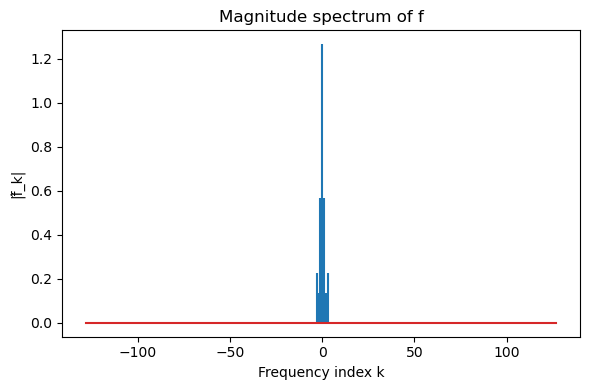

In [19]:
# Step 3 – magnitude spectrum
plt.figure(figsize=(6, 4))
plt.stem(freqs, np.abs(F_shift), markerfmt=" ")
plt.xlabel("Frequency index k")
plt.ylabel("|f̂_k|")
plt.title("Magnitude spectrum of f")
plt.tight_layout()
plt.show()

In [29]:
# Step 4 – truncate: keep only |k| ≤ 10
k_max = 5
mask = np.abs(np.fft.fftfreq(N, d=1/N)) > k_max
F_hat_trunc = F_hat.copy()
F_hat_trunc[mask] = 0

# Step 4b – inverse FFT to reconstruct
f_trunc = np.fft.ifft(F_hat_trunc).real


In [30]:
# Step 5 – error
rms_error = np.sqrt(np.mean((f - f_trunc)**2))
print(f"RMS error with k_max={k_max}: {rms_error:.3e}")

RMS error with k_max=5: 3.188e-05


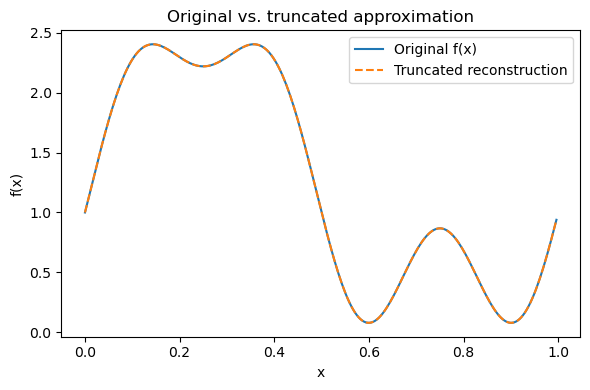

In [31]:
# Step 6 – visual comparison
plt.figure(figsize=(6, 4))
plt.plot(x, f, label="Original f(x)")
plt.plot(x, f_trunc, linestyle="--", label="Truncated reconstruction")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.title("Original vs. truncated approximation")
plt.tight_layout()
plt.show()

### Commentary
With only 21 non‑zero Fourier modes (\(k=-10,\dots,10\)), the reconstruction already captures the main features of \(f\). The RMS error reported above quantifies the approximation quality. Increasing \(k_{max}\) would further reduce the error, while decreasing it would smooth the signal more aggressively.